In [518]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from lib import spoti
import json
import os
from typing import List, Dict, Tuple
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np

In [519]:
DATA_PATH = os.path.join("data")

# Data users & cleaning

In [520]:
owen = spoti.SpotiUser("owen")
brenda = spoti.SpotiUser("brenda")
arthur = spoti.SpotiUser("arthur")
michelle = spoti.SpotiUser("michelle")
paul = spoti.SpotiUser("paul")
jaslkh = spoti.SpotiUser("jaslkh")
lsirwguhu = spoti.SpotiUser("lsirwguhu")

In [521]:
USERS = [jaslkh, owen, brenda, arthur, michelle, paul, lsirwguhu]

In [522]:
def get_data_path(user: spoti.SpotiUser) -> str:
    return os.path.join(DATA_PATH, f"{user.username}_top_tracks.json")

In [523]:
def simplify_genre(genres: List[str]) -> List[str]:
    for i, genre in enumerate(genres):
        if "rock" in genre: genres[i] = "rock"
        if "pop" in genre: genres[i] = "pop"
        if "rap" in genre: genres[i] = "rap"
        if "hip hop" in genre: genres[i] = "rap"
        if "emo" in genre or "punk" in genre or "screamo" in genre or "hardcore" in genre or "dreamo" in genre or "grunge" in genre: genres[i] = "emo/punk/grunge"
        if "metal" in genre: genres[i] = "metal"
        if "lo-fi" in genre or "chill" in genre or "lofi" in genre: genres[i] = "lo-fi"
        if "indie" in genre: genres[i] = "indie"
        if "french" in genre or "francophone" in genre or "francais" in genre: genres[i] = "french"
        if "house" in genre or "edm" in genre or "electro" in genre or "electronic" in genre: genres[i] = "electronic"
        if "jazz" in genre: genres[i] = "jazz"
        if "classical" in genre: genres[i] = "classical"
        if "r&b" in genre or "soul" in genre: genres[i] = "r&b"
    return list(set(genres))

USERS_DF = []
for user in USERS:
    df = pd.read_json(get_data_path(user), orient="records")
    df["simplified_genres"] = df["genres"].apply(simplify_genre)
    df["username"] = user.username
    USERS_DF.append(df)

df = pd.concat(USERS_DF)

In [524]:
penality_factors = {
    "short_term": 1,
    "medium_term": 0.75,
    "long_term": 0.5
}

for user, df_sub_user in df.groupby("username"):
    for time_range, df_sub_user_time_range in df_sub_user.groupby("time_range"):
        # Add affinity column, to goes from 0 to 1, it's just a incremental index
        size = len(df_sub_user_time_range)
        penality_factor = penality_factors[time_range]
        df_sub_user_time_range["affinity"] = range(1, size + 1)[::-1]
        df.loc[df_sub_user_time_range.index, "affinity"] = (df_sub_user_time_range["affinity"] * penality_factor) / size

df = df.reset_index(drop=True)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,simplified_genres,username,affinity
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,audio_features,spotify:track:75rqqKvzJCGv2oq9C4yFDt,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,https://api.spotify.com/v1/audio-analysis/75rq...,196427,4,medium_term,"[pop, r&b]",jaslkh,0.750
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,audio_features,spotify:track:2FYGZDfsAnNsrm1gVbyKnG,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,https://api.spotify.com/v1/audio-analysis/2FYG...,137533,4,medium_term,"[pop, r&b]",jaslkh,0.735
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,audio_features,spotify:track:4kroNlz8BTfswE4M0i3YCh,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,https://api.spotify.com/v1/audio-analysis/4kro...,162907,3,medium_term,"[pop, r&b]",jaslkh,0.720
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,audio_features,spotify:track:2N3YZ075lq9z1ObaAiX6l1,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,https://api.spotify.com/v1/audio-analysis/2N3Y...,89749,4,medium_term,"[pop, r&b]",jaslkh,0.705
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,audio_features,spotify:track:2SiAcexM2p1yX6joESbehd,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,https://api.spotify.com/v1/audio-analysis/2SiA...,174045,4,medium_term,"[pop, r&b]",jaslkh,0.690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,227093,False,{'isrc': 'QM24S2004459'},{'spotify': 'https://open.spotify.com/track/4A...,https://api.spotify.com/v1/tracks/4AssfJK5W9zn...,4AssfJK5W9zn2N1qdmeARM,...,audio_features,spotify:track:4AssfJK5W9zn2N1qdmeARM,https://api.spotify.com/v1/tracks/4AssfJK5W9zn...,https://api.spotify.com/v1/audio-analysis/4Ass...,227094,4,long_term,"[pop, r&b]",lsirwguhu,0.050
1046,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,134482,True,{'isrc': 'USAT22100334'},{'spotify': 'https://open.spotify.com/track/4K...,https://api.spotify.com/v1/tracks/4Kh6cq3XgOGU...,4Kh6cq3XgOGUK9yXQu7RTq,...,audio_features,spotify:track:4Kh6cq3XgOGUK9yXQu7RTq,https://api.spotify.com/v1/tracks/4Kh6cq3XgOGU...,https://api.spotify.com/v1/audio-analysis/4Kh6...,134483,4,long_term,"[electronic, pop, alt z]",lsirwguhu,0.040
10

# Analysis on the users

In [525]:
px.pie(df, names="username", title="Number of Liked Tracks per User")

In [526]:
def count_list_column_per_user(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df_count = df.explode(column)
    df_count = df_count.groupby([column, "username"]).count().reset_index()
    df_count = df_count.rename(columns={"id": "count"})
    df_count = df_count[[column, "username", "count"]]
    df_count["count"] = df_count["count"] / df_count.groupby("username")["count"].transform("sum")
    df_count = df_count.sort_values("count", ascending=False)
    return df_count

In [527]:
# Turn dataset into a list of genres
df_count_genre = count_list_column_per_user(df, "simplified_genres")
px.bar(df_count_genre.groupby("username").head(20), x="simplified_genres", y="count", color="username", title="Number of Liked Tracks per Genre", barmode="group")

In [528]:
df["artists_names"] = df["artists"].apply(lambda x: [artist["name"] for artist in x])
df_count_artists = count_list_column_per_user(df, "artists_names")
px.bar(df_count_artists.groupby("username").head(100), x="artists_names", y="count", color="username", title="Number of liked artists per user", barmode="group")

In [529]:
user_top_likes = owen
time_ranges = ["short_term", "medium_term", "long_term"]

top_tracks = df[(df["username"] == user_top_likes.username) & (df["time_range"].isin(time_ranges))] \
    .sort_values("popularity", ascending=False) \
    .sort_values("time_range", ascending=False) \
    .apply(lambda x: f"{x['artists'][0]['name']} - {x['name']} ({x['time_range']})", axis=1) \
    .to_list()

# print("\n".join(top_tracks))

In [530]:
numeric_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "loudness",
    "duration_ms",
]

<Figure size 2000x1000 with 0 Axes>

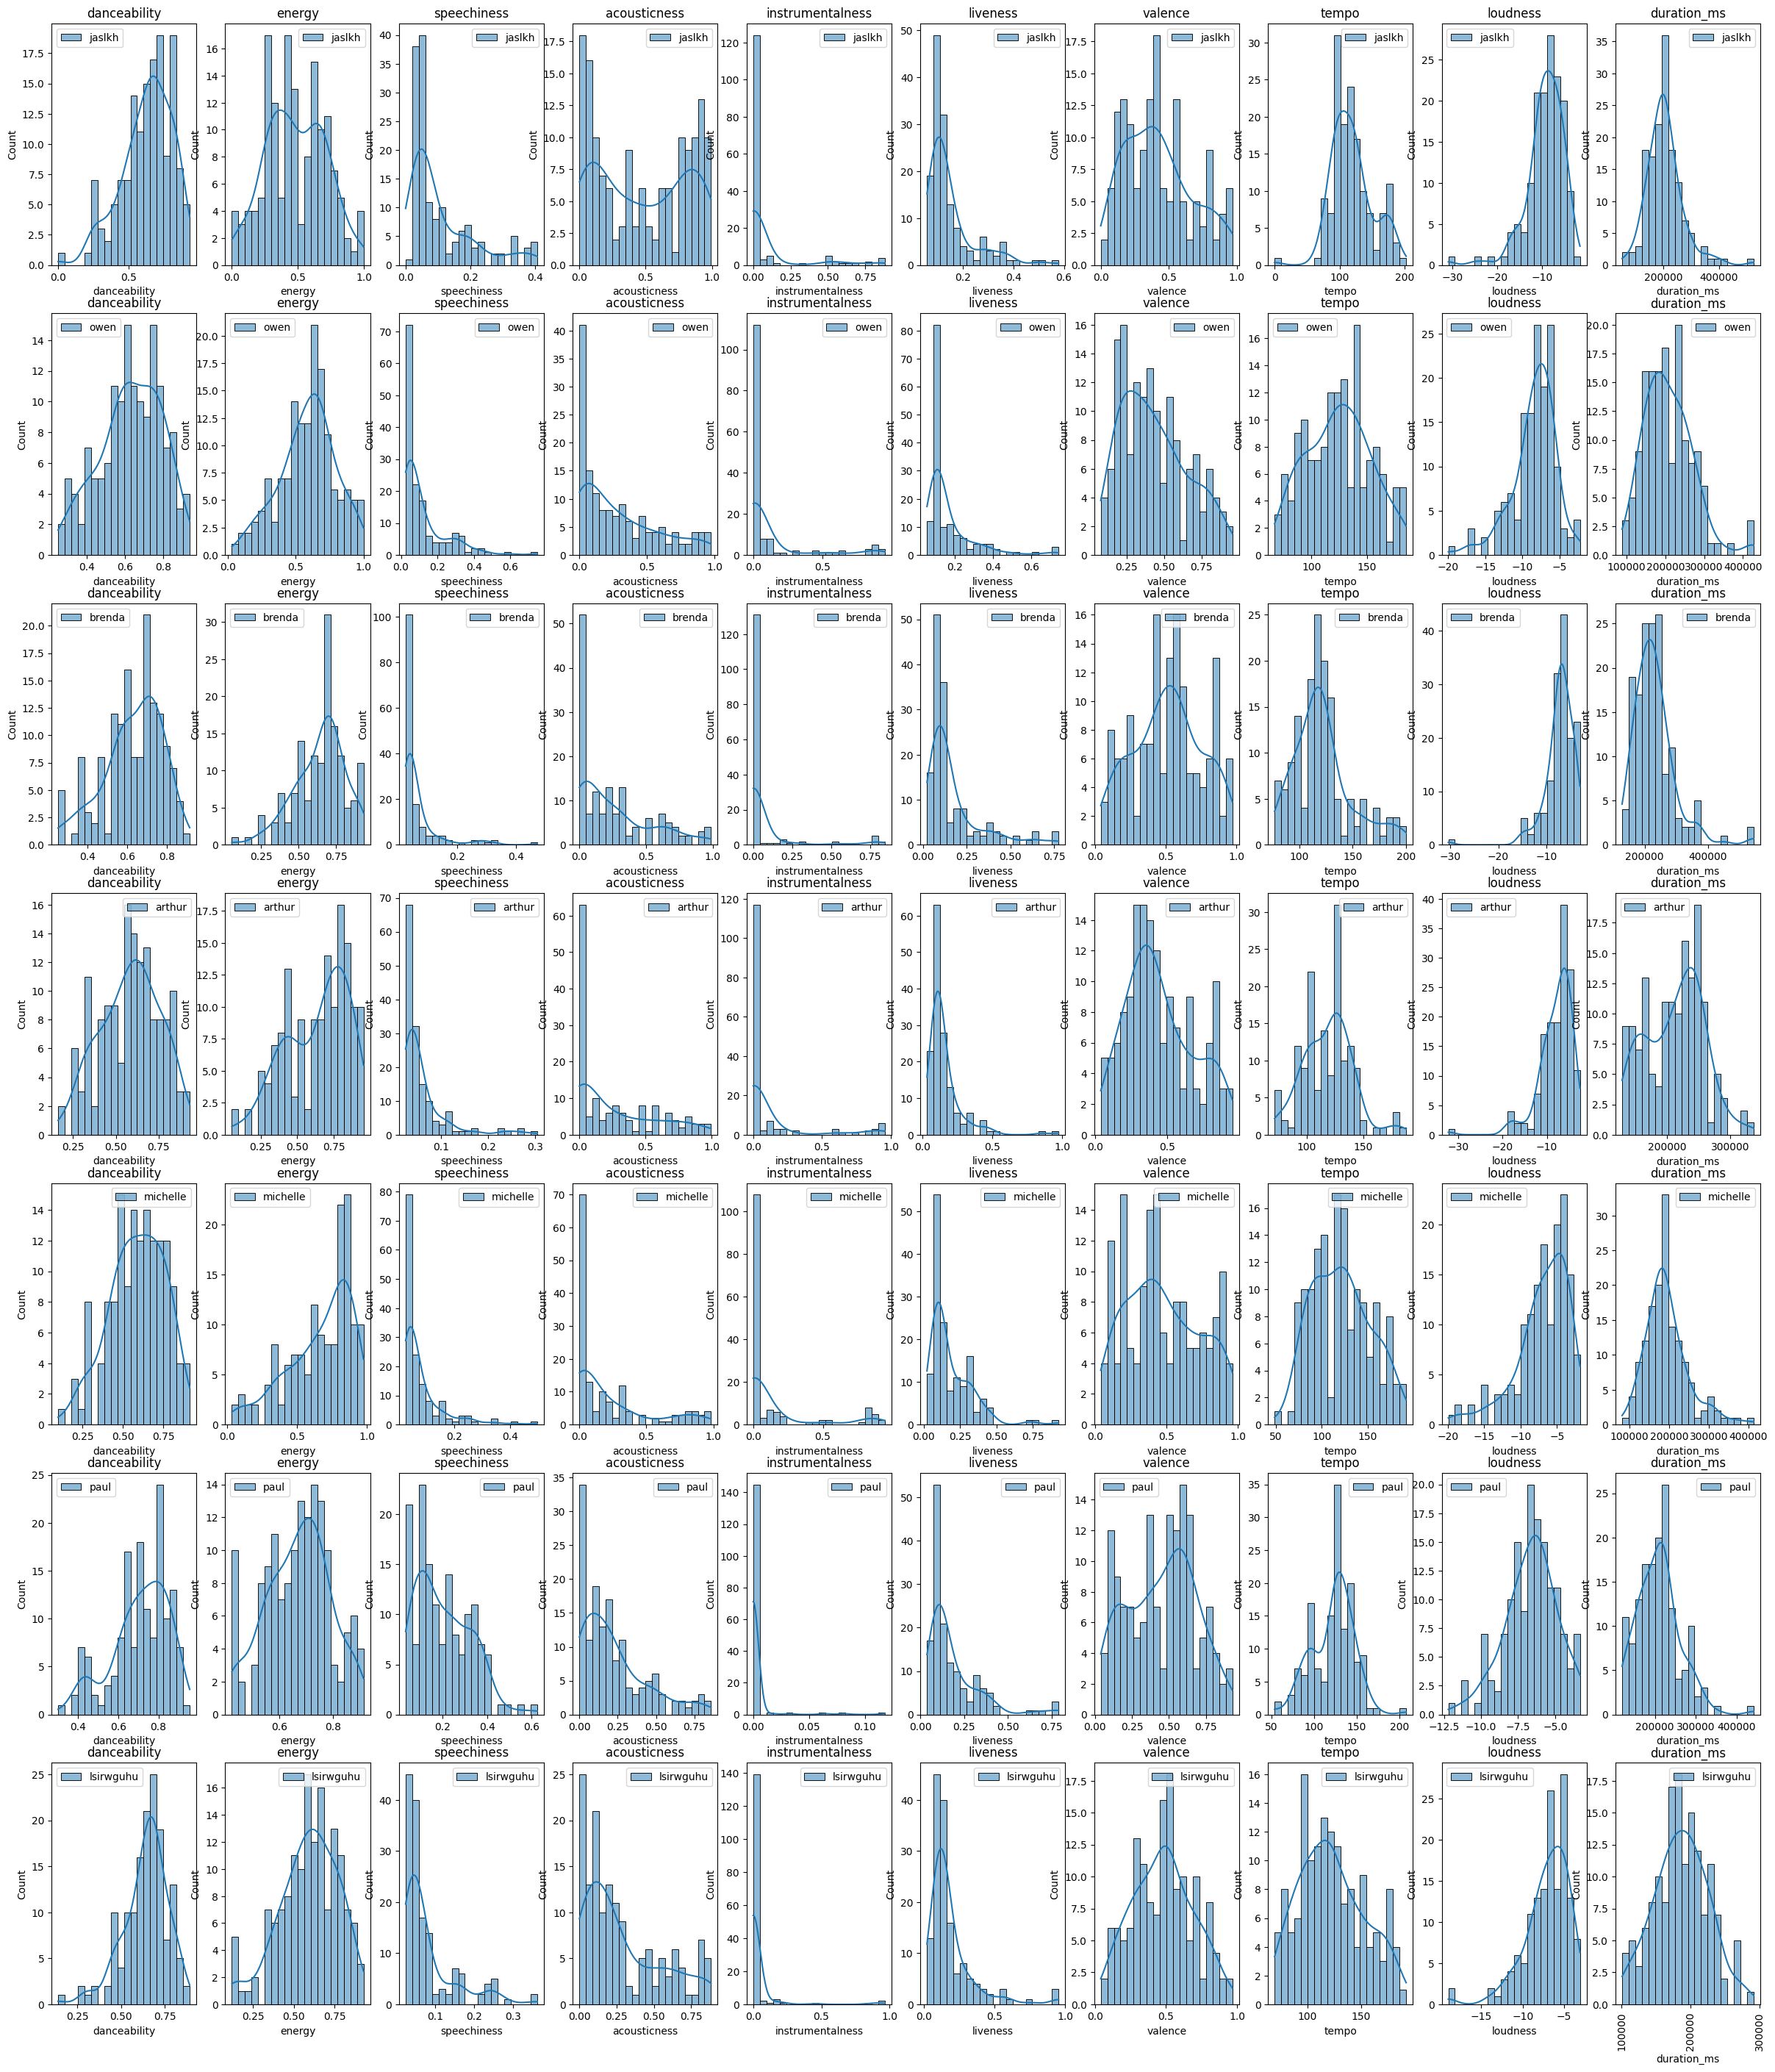

In [531]:
plt.figure(figsize=(20,10))

fig, axs = plt.subplots(len(USERS), len(numeric_features), figsize=(30, len(USERS)*5))

for i, user in enumerate(USERS):
    # Show features distribution for each user
    user_top_tracks = USERS_DF[i]
    for i, feature in enumerate(numeric_features):
        sns.histplot(x=feature, data=user_top_tracks, ax=axs[USERS.index(user), i], bins=20, kde=True, label=user.username)
        axs[USERS.index(user), i].set_title(feature)
        axs[USERS.index(user), i].legend()

plt.legend()
plt.xticks(rotation=90)
plt.show()

In [532]:
def plot_latent_space(df: pd.DataFrame, dim: int, color: pd.Series, text: pd.Series) -> None:
    """
    The latent space is the space where we will project our data, it is the space where we will be able to see the similarities between
    data points. To make it simple, if two data points are close in the latent space, it means that they are similar.
    :param df: dataframe containing the latent space (columns: latent_0, latent_1, ...)
    :return: None
    """

    if color is None:
        color = df.index
    if text is None:
        text = df.index

    if dim == 2:
        # Plot 2D latent space
        fig = go.Figure(data=go.Scatter(
            x=df["latent_0"],
            y=df["latent_1"],
            mode="markers+text",
            text=text,
            textposition="bottom center",
            marker=dict(
                size=10,
                # random color for each user
                color=color.map(lambda x: hash(x) % 100),
                colorscale="Bluered",
                showscale=False
            )
        ))
        # Set title
        fig.update_layout(title_text=f"Latent Space ({dim}D)")
        return fig
    elif dim == 3:
        # Plot 3D latent space
        fig = px.scatter_3d(df, x="latent_0", y="latent_1", z="latent_2", color=color, text=text, opacity=0.5)
        fig.update_traces(textposition="top center")
        fig.update_layout(
            margin=dict(l=0, r=0, b=0, t=0),
            scene = dict(
                xaxis_title="latent_0",
                yaxis_title="latent_1",
                zaxis_title="latent_2",
            )
        )
        # Set title
        fig.update_layout(title_text=f"Latent Space ({dim}D)")
        return fig
    else:
        # Pairplot
        fig = px.scatter_matrix(df, dimensions=[f"latent_{i}" for i in range(dim)], color=color, opacity=0.5)
        # Set title
        fig.update_layout(title_text=f"Latent Space ({dim}D)")
        return fig

# PCA

In [533]:
df_tracks_only = pd.read_json(os.path.join(DATA_PATH, "tracks.json"), orient="records")
df_tracks_only["username"] = "No user"
df_tracks_only["time_range"] = "No time range"
df_tracks_only["affinity"] = 0

In [534]:
df_all = df.copy()
df_all = pd.concat([df_all, df_tracks_only], ignore_index=True)
# Remove duplicates
df_all = df_all.drop_duplicates(subset=["id"])
df_all

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_signature,time_range,simplified_genres,username,affinity,episode,track,added_at,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,4,medium_term,"[pop, r&b]",jaslkh,0.750,NaN,NaN,NaT,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,4,medium_term,"[pop, r&b]",jaslkh,0.735,NaN,NaN,NaT,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,3,medium_term,"[pop, r&b]",jaslkh,0.720,NaN,NaN,NaT,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,4,medium_term,"[pop, r&b]",jaslkh,0.705,NaN,NaN,NaT,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,4,medium_term,"[pop, r&b]",jaslkh,0.690,NaN,NaN,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3850,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,208400,False,{'isrc': 'USKO11502353'},{'spotify': 'https://open.spotify.com/track/2w...,https://api.spotify.com/v1/tracks/2wS5yNEN2Bsw...,2wS5yNEN2Bsw9smRBxBL6F,...,4,No time range,NaN,No user,0.000,False,True,2023-10-14 20:56:19+00:00,nicksinger7510,5zwLw7HmUqTZAXwOTqIdqy
3851,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,177569,False,{'isrc': 'QM24S2300334'},{'spotify': 'https://open.spotify.com/track/1g...,https://api.spotify.com/v1/tracks/1gOXJCXmQ7lV...,1gOXJCXmQ7lVDdjxyHqfF4,...,4,No time range,NaN,No user,0.000,False,True,2023-10-20 07:58:01+00:00,nicksinger7510,5zwLw7HmUqTZAXwOTqIdqy
3852,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,187699,False,{'isrc': 'USUM72306520'},{'spotify': 'https://open.spotify.com/track/2u...,https://api.spotify.com/v1/tracks/2uqCJn5VFTf3...,2uqCJn5VFTf3sZEDJZvvX0,...,4,No time range,NaN,No user,0.000,False,True,2023-10-26 20:52:05+00:00,nicksinger7510,5zwLw7HmUqTZAXwOTqIdqy
3853,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,212013,True,{'isrc': 'USAT20402871'},{'spotify': 'https://open.spotify.com/track/5w...,https://api.spotify.com/v1/tracks/5wK87f6MxR78...,5wK87f6MxR78H9XnnwkRQ5,...,4,No time range,NaN,No user,0.000,False,True,2023-11-09 20:48:57+00:00,nicksinger7510,5zwLw7HmUqTZAXwOTqIdqy


In [535]:
# Scale the numeric features of df
scaler = StandardScaler()
df_all_scaled = df_all.copy()
df_all_scaled[numeric_features] = scaler.fit_transform(df_all_scaled[numeric_features])
df_all_scaled[numeric_features]

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms
0,0.423217,-1.872460,2.314155,3.188607,-0.279176,0.661919,-0.692423,-0.679431,-0.645604,-0.562774
1,1.749118,0.192261,2.877786,2.871311,-0.279530,1.971072,0.889614,-0.855355,0.402236,-1.625778
2,0.106886,-2.275972,4.969155,3.269048,-0.279700,-0.415068,-1.051777,0.004998,-1.364033,-1.167801
3,0.564557,-2.118759,4.909825,3.488027,-0.279700,0.216936,0.087640,0.396232,-0.982625,-2.488267
4,-0.081567,-0.509954,2.996446,-0.082666,-0.279684,-0.021678,0.105169,1.632448,0.459304,-0.966763
...,...,...,...,...,...,...,...,...,...,...
3850,0.241495,1.004524,-0.018981,-0.621533,-0.279700,-0.715593,0.350582,-0.463979,1.160929,-0.346646
3851,-0.216177,0.391397,-0.594478,-0.652011,-0.279683,-0.725267,-0.709952,-1.704091,0.624486,-0.903138
3852,0.503983,-0.069759,-0.406107,-0.648212,-0.279510,-0.878754,1.542587,-0.323297,0.615609,-0.720294
3853,-0.270020,0.784427,-0.459504,-0.648749,-0.279700,-0.486008,-0.280480,0.998667,0.599122,-0.281432


In [536]:
df_top_tracks_scaled = df.copy()
df_top_tracks_scaled[numeric_features] = scaler.transform(df_top_tracks_scaled[numeric_features])
df_top_tracks_scaled[numeric_features]

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms
0,0.423217,-1.872460,2.314155,3.188607,-0.279176,0.661919,-0.692423,-0.679431,-0.645604,-0.562774
1,1.749118,0.192261,2.877786,2.871311,-0.279530,1.971072,0.889614,-0.855355,0.402236,-1.625778
2,0.106886,-2.275972,4.969155,3.269048,-0.279700,-0.415068,-1.051777,0.004998,-1.364033,-1.167801
3,0.564557,-2.118759,4.909825,3.488027,-0.279700,0.216936,0.087640,0.396232,-0.982625,-2.488267
4,-0.081567,-0.509954,2.996446,-0.082666,-0.279684,-0.021678,0.105169,1.632448,0.459304,-0.966763
...,...,...,...,...,...,...,...,...,...,...
1045,-0.303673,-0.599041,-0.615244,-0.163108,-0.279700,-0.681413,-0.105185,-1.283495,0.004976,-0.009242
1046,0.349182,-1.201688,2.640468,0.136312,-0.279700,-0.234496,-0.661746,1.772989,-0.357092,-1.680848
1047,0.726088,-0.850580,-0.446154,-0.140763,-0.279700,-0.170005,0.477671,1.486488,0.194887,-0.953118
1048,1.399134,-0.620002,-0.248883,-0.172045,-0.279538,-0.369925,1.165703,-0.852592,0.756060,-0.339679


In [537]:
from typing import Callable

def q25(x: pd.Series) -> float:
    return x.quantile(0.25)

def q75(x: pd.Series) -> float:
    return x.quantile(0.75)

def get_users_df(df: pd.DataFrame, agg: List[str], name: Callable[[str], str]) -> pd.DataFrame:
    df_features_user = df.groupby("username")[numeric_features].agg(agg).reset_index()
    df_features_user.columns = ["username"] + [name(col, agg) for col, agg in df_features_user.columns[1:]]
    df_features_user.set_index("username", inplace=True)
    return df_features_user

df_features_user = get_users_df(df_all_scaled, ["mean", "median", q25, q75, "std", "min", "max"], lambda col, agg: f"{col}_{agg}")
user_features_list = list(df_features_user.columns)
df_features_user

,danceability_mean,danceability_median,danceability_q25,danceability_q75,danceability_std,danceability_min,danceability_max,energy_mean,energy_median,energy_q25,...,loudness_std,loudness_min,loudness_max,duration_ms_mean,duration_ms_median,duration_ms_q25,duration_ms_q75,duration_ms_std,duration_ms_min,duration_ms_max
username,,,,,,,,,,,,,,,,,,,,,
No user,-0.118776,-0.101759,-0.734422,0.524174,0.940646,-2.874709,2.778879,0.192079,0.407118,-0.305578,...,0.956362,-4.196848,2.056904,0.110408,-0.023682,-0.534490,0.607338,0.960437,-2.888539,5.570533
arthur,0.107429,0.160729,-0.751248,0.924637,1.189264,-2.726639,2.455817,-0.492623,-0.232212,-1.466329,...,1.361442,-8.037238,1.421859,-0.234384,-0.106711,-0.972503,0.364514,0.850752,-1.799290,1.987783
brenda,0.430689,0.551096,-0.054646,1.082802,0.952090,-2.127628,2.341399,-0.494757,-0.305578,-1.028754,...,1.058964,-7.403461,1.211340,0.031665,-0.139200,-0.660712,0.389784,1.157878,-1.783172,5.722151
jaslkh,0.368361,0.564557,-0.317134,1.217412,1.204985,-3.816974,2.442356,-1.269833,-1.327458,-2.218327,...,1.316333,-7.595592,1.721786,-0.416454,-0.525465,-1.159697,0.048030,1.177308,-3.196341,5.385956
lsirwguhu,0.471936,0.591479,0.032850,1.042420,0.924468,-2.874709,2.193329,-0.736445,-0.703849,-1.306496,...,0.853863,-3.803710,1.229412,-0.800734,-0.809442,-1.304492,-0.296107,0.719854,-2.284251,1.161104
michelle,0.132691,0.187651,-0.572891,1.022228,1.113027,-3.146620,2.334668,-0.433650,-0.206010,-1.201688,...,1.161657,-4.109660,1.627623,-0.556972,-0.733542,-1.154932,-0.058482,1.019711,-2.633099,3.352579
owen,0.473507,0.497252,-0.209446,1.264525,1.037333,-1.824757,2.496199,-0.780292,-0.730051,-1.489910,...,0.934308,-4.128049,1.496999,-0.396984,-0.533678,-1.162477,0.221253,1.087926,-2.519114,3.623578
paul,0.973070,1.116455,0.440043,1.700322,0.941037,-1.784374,2.610617,-0.360088,-0.295097,-0.804727,...,0.569638,-1.661740,1.156491,-0.307649,-0.349001,-0.970928,0.098154,0.951554,-1.956991,3.876690


In [538]:
def get_user_track_df(username: str, df_all: pd.DataFrame, df_features_user: pd.Series) -> pd.DataFrame:
    df_user = df_all.copy()
    # Impute the affinity of the user by using the features of the user
    user_mean = get_users_df(df_all, ["mean"], lambda col, agg: f"{col}").loc[username]
    df_user.loc[df_user["username"] != username, "affinity"] = df_user.loc[df_user["username"] != username, numeric_features].apply(lambda x: np.linalg.norm(x - user_mean) / len(numeric_features), axis=1)
    # normalize affinity
    df_user["affinity"] = df_user["affinity"] / df_user["affinity"].max()
    df_user["original_username"] = df_user["username"]
    df_user["username"] = username
    # Add user features
    df_user = pd.merge(df_user, df_features_user, on="username")
    return df_user

In [539]:
df_users_tracks = pd.DataFrame()
for user in USERS:
    df_user = get_user_track_df(user.username, df_all_scaled, df_features_user)
    df_users_tracks = pd.concat([df_users_tracks, df_user], ignore_index=True)
    # MinMax scale the affinity
df_users_tracks[["username", "affinity", *numeric_features, *user_features_list]]

,username,affinity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,...,loudness_std,loudness_min,loudness_max,duration_ms_mean,duration_ms_median,duration_ms_q25,duration_ms_q75,duration_ms_std,duration_ms_min,duration_ms_max
0,jaslkh,0.728858,0.423217,-1.872460,2.314155,3.188607,-0.279176,0.661919,-0.692423,-0.679431,...,1.316333,-7.595592,1.721786,-0.416454,-0.525465,-1.159697,0.048030,1.177308,-3.196341,5.385956
1,jaslkh,0.714281,1.749118,0.192261,2.877786,2.871311,-0.279530,1.971072,0.889614,-0.855355,...,1.316333,-7.595592,1.721786,-0.416454,-0.525465,-1.159697,0.048030,1.177308,-3.196341,5.385956
2,jaslkh,0.699704,0.106886,-2.275972,4.969155,3.269048,-0.279700,-0.415068,-1.051777,0.004998,...,1.316333,-7.595592,1.721786,-0.416454,-0.525465,-1.159697,0.048030,1.177308,-3.196341,5.385956
3,jaslkh,0.685127,0.564557,-2.118759,4.909825,3.488027,-0.279700,0.216936,0.087640,0.396232,...,1.316333,-7.595592,1.721786,-0.416454,-0.525465,-1.159697,0.048030,1.177308,-3.196341,5.385956
4,jaslkh,0.670550,-0.081567,-0.509954,2.996446,-0.082666,-0.279684,-0.021678,0.105169,1.632448,...,1.316333,-7.595592,1.721786,-0.416454,-0.525465,-1.159697,0.048030,1.177308,-3.196341,5.385956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25118,lsirwguhu,0.242939,0.241495,1.004524,-0.018981,-0.621533,-0.279700,-0.715593,0.350582,-0.463979,...,0.853863,-3.803710,1.229412,-0.800734,-0.809442,-1.304492,-0.296107,0.719854,-2.284251,1.161104
25119,lsirwguhu,0.252825,-0.216177,0.391397,-0.594478,-0.652011,-0.279683,-0.725267,-0.709952,-1.704091,...,0.853863,-3.803710,1.229412,-0.800734,-0.809442,-1.304492,-0.296107,0.719854,-2.284251,1.161104
25120,lsirwguhu,0.233185,0.503983,-0.069759,-0.406107,-0.648212,-0.279510,-0.878754,1.542587,-0.323297,...,0.853863,-3.803710,1.229412,-0.800734,-0.809442,-1.304492,-0.296107,0.719854,-2.284251,1.161104
25121,lsirwguhu,0.233668,-0.270020,0.784427,-0.459504,-0.648749,-0.279700,-0.486008,-0.280480,0.998667,...,0.853863,-3.803710,1.229412,-0.800734,-0.809442,-1.304492,-0.296107,0.719854,-2.284251,1.161104


In [540]:
assert len(df_users_tracks) == len(USERS) * len(df_all), "df_users_tracks should have the same length as USERS * df_all"

In [541]:
# shuffle df_users_tracks
df_users_tracks = df_users_tracks.sample(frac=1).reset_index(drop=True)
df_users_tracks[["username", "affinity", *numeric_features, *user_features_list]]

,username,affinity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,...,loudness_std,loudness_min,loudness_max,duration_ms_mean,duration_ms_median,duration_ms_q25,duration_ms_q75,duration_ms_std,duration_ms_min,duration_ms_max
0,arthur,0.335202,-0.660387,1.245583,-0.179171,-0.618941,-0.279623,0.997268,-0.241038,1.413348,...,1.361442,-8.037238,1.421859,-0.234384,-0.106711,-0.972503,0.364514,0.850752,-1.799290,1.987783
1,michelle,0.286596,-1.097867,1.366113,0.638094,-0.657861,1.509006,-0.215149,-0.692423,0.755235,...,1.161657,-4.109660,1.627623,-0.556972,-0.733542,-1.154932,-0.058482,1.019711,-2.633099,3.352579
2,owen,0.378542,0.355913,-0.258414,4.183038,-0.216735,-0.279700,-0.382823,0.766907,0.752579,...,0.934308,-4.128049,1.496999,-0.396984,-0.533678,-1.162477,0.221253,1.087926,-2.519114,3.623578
3,michelle,0.209615,0.308799,0.810629,0.593597,-0.487107,-0.272817,0.468448,-0.188450,0.569252,...,1.161657,-4.109660,1.627623,-0.556972,-0.733542,-1.154932,-0.058482,1.019711,-2.633099,3.352579
4,brenda,0.217217,1.594318,-0.185048,0.280633,-0.619969,-0.272845,0.790900,0.552171,-1.006486,...,1.058964,-7.403461,1.211340,0.031665,-0.139200,-0.660712,0.389784,1.157878,-1.783172,5.722151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25118,paul,0.292998,0.328991,1.345151,-0.113909,-0.611790,-0.180173,1.023065,-0.977277,-0.821920,...,0.569638,-1.661740,1.156491,-0.307649,-0.349001,-0.970928,0.098154,0.951554,-1.956991,3.876690
25119,michelle,0.258003,-1.346894,0.532888,-0.352710,-0.358848,-0.279700,0.765104,-0.793217,-0.262766,...,1.161657,-4.109660,1.627623,-0.556972,-0.733542,-1.154932,-0.058482,1.019711,-2.633099,3.352579
25120,arthur,0.196168,0.961654,0.480483,-0.038263,-0.214501,-0.279700,0.616776,0.319905,-0.076642,...,1.361442,-8.037238,1.421859,-0.234384,-0.106711,-0.972503,0.364514,0.850752,-1.799290,1.987783
25121,arthur,0.206177,0.100155,0.040289,-0.615244,-0.547438,-0.279341,-0.556947,-0.262950,-1.563125,...,1.361442,-8.037238,1.421859,-0.234384,-0.106711,-0.972503,0.364514,0.850752,-1.799290,1.987783


# To torch

In [542]:
y_features = ["affinity"]
track_features_list = numeric_features
user_features_list = user_features_list

# Create Dev (Train + Validation) and Test sets
from sklearn.model_selection import train_test_split
X_dev_users, X_test_users, X_dev_tracks, X_test_tracks, y_dev, y_test = train_test_split(
    df_users_tracks[user_features_list],
    df_users_tracks[track_features_list],
    df_users_tracks[y_features],
    test_size=0.01,
    random_state=42,
    shuffle=False
)
X_train_users, X_val_users, X_train_tracks, X_val_tracks, y_train, y_val = train_test_split(
    X_dev_users,
    X_dev_tracks,
    y_dev,
    test_size=0.01,
    random_state=42,
    shuffle=False
)
print(f"Train size: {len(X_train_users)}")
print(f"Val size: {len(X_val_users)}")
print(f"Test size: {len(X_test_users)}")

Train size: 24622
Val size: 249
Test size: 252


In [543]:
# Convert to torch tensors
X_train_users = torch.tensor(X_train_users.values, dtype=torch.float)
X_train_tracks = torch.tensor(X_train_tracks.values, dtype=torch.float)
y_train = torch.tensor(y_train.values, dtype=torch.float)

X_val_users = torch.tensor(X_val_users.values, dtype=torch.float)
X_val_tracks = torch.tensor(X_val_tracks.values, dtype=torch.float)
y_val = torch.tensor(y_val.values, dtype=torch.float)

X_test_users = torch.tensor(X_test_users.values, dtype=torch.float)
X_test_tracks = torch.tensor(X_test_tracks.values, dtype=torch.float)
y_test = torch.tensor(y_test.values, dtype=torch.float)

# Create a dataset class
train_dataset = torch.utils.data.TensorDataset(X_train_users, X_train_tracks, y_train)
val_dataset = torch.utils.data.TensorDataset(X_val_users, X_val_tracks, y_val)
test_dataset = torch.utils.data.TensorDataset(X_test_users, X_test_tracks, y_test)

# Create a dataloader
BATCH_SIZE = 32
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## NN

In [544]:
# Create a model that would predict the affinity of a user for a track
class UserTrackAffinityModel(nn.Module):
    def __init__(self, user_features: int, track_features: int, latent_dim: int = 8):
        super().__init__()

        self.encode = nn.Sequential(
            nn.Linear(user_features + track_features, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.regression = nn.Sequential(
            nn.Linear(latent_dim, 1),
        )

    def forward(self, user_features: torch.Tensor, track_features: torch.Tensor) -> torch.Tensor:
        """
        Predict the affinity of a user for a track based on the user and track features
        :param user_features: user features
        :param track_features: track features
        :return: affinity as a float between 0 and 1
        """
        # Concatenate user and track features
        x = torch.cat([user_features, track_features], dim=1)
        # Encode
        x = self.encode(x)
        # Regression
        x = self.regression(x)
        # Output value from -1 to 1
        x = torch.sigmoid(x)
        return x

In [545]:
# Parameters
user_features_size = len(user_features_list)
track_features_size = len(track_features_list)
print(f"User features size: {user_features_size}")
print(f"Track features size: {track_features_size}")
print(f"User + Track features size: {user_features_size + track_features_size}")
hidden_dim = 32

User features size: 70
Track features size: 10
User + Track features size: 80


In [546]:
# Choose the loss and optimizer
model = UserTrackAffinityModel(user_features_size, track_features_size, hidden_dim)
optimizer = optim.Adam(model.parameters(), lr=0.000001)

# Loss
criterion = nn.MSELoss()

In [547]:
## Train a neural network on the data
EPOCHS = 100
losses = []
val_losses = []
for epoch in range(EPOCHS):
    for i, data in enumerate(train_dataloader):
        # Get the inputs
        user_features, track_features, affinity = data

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(user_features, track_features)
        
        # The output is a float between 0 and 1, we want to compare it to the affinity
        # which is also a float between 0 and 1
        loss = criterion(outputs, affinity)
        loss.backward()
        optimizer.step()
        
    losses.append(loss.item())

    # Compute validation loss
    with torch.no_grad():
        for i, data in enumerate(val_dataloader):
            # Get the inputs
            user_features, track_features, affinity = data

            # Forward
            outputs = model(user_features, track_features)
            val_loss = criterion(outputs, affinity)
        
        val_losses.append(val_loss.item())
    
    print(f"Epoch {epoch + 1}/{EPOCHS} - Loss: {loss.item():.8f} - Val Loss: {val_loss.item():.8f}")

Epoch 1/100 - Loss: 0.02259272 - Val Loss: 0.03343703
Epoch 2/100 - Loss: 0.02013266 - Val Loss: 0.03048065
Epoch 3/100 - Loss: 0.01761191 - Val Loss: 0.02739686
Epoch 4/100 - Loss: 0.01498053 - Val Loss: 0.02421797
Epoch 5/100 - Loss: 0.01232016 - Val Loss: 0.02094880
Epoch 6/100 - Loss: 0.00980933 - Val Loss: 0.01776211
Epoch 7/100 - Loss: 0.00762129 - Val Loss: 0.01486803
Epoch 8/100 - Loss: 0.00586760 - Val Loss: 0.01242836
Epoch 9/100 - Loss: 0.00463526 - Val Loss: 0.01055273
Epoch 10/100 - Loss: 0.00388147 - Val Loss: 0.00925832
Epoch 11/100 - Loss: 0.00348496 - Val Loss: 0.00847365
Epoch 12/100 - Loss: 0.00328372 - Val Loss: 0.00805422
Epoch 13/100 - Loss: 0.00316897 - Val Loss: 0.00783835
Epoch 14/100 - Loss: 0.00309249 - Val Loss: 0.00772086
Epoch 15/100 - Loss: 0.00303344 - Val Loss: 0.00764972
Epoch 16/100 - Loss: 0.00297880 - Val Loss: 0.00759716
Epoch 17/100 - Loss: 0.00292472 - Val Loss: 0.00755081
Epoch 18/100 - Loss: 0.00286868 - Val Loss: 0.00750049
Epoch 19/100 - Loss

In [548]:
go.Figure(data=[
    go.Scatter(x=list(range(len(losses))), y=losses, name="Train loss"), 
    go.Scatter(x=list(range(len(val_losses))), y=val_losses, name="Val loss"),
]).update_layout(title="Losses")

In [549]:
# Test
model.eval()
epoch_loss = 0
for i, (user_features, track_features, labels) in enumerate(test_dataloader):
    # Forward
    outputs = model(user_features, track_features)
    loss = criterion(outputs, labels)
    # Save loss
    epoch_loss += loss.item()
print(f"Test loss: {epoch_loss / len(test_dataloader)}")

Test loss: 0.004007987285149284


In [550]:
df_predict = get_user_track_df("paul", df_top_tracks_scaled, df_features_user)
# drop duplicates
df_predict = df_predict.drop_duplicates(subset=["id"])
print(df_predict[user_features_list].iloc[0].to_numpy())

# Predict
model.eval()
X_predict_users = torch.tensor(df_predict[user_features_list].values, dtype=torch.float)
X_predict_tracks = torch.tensor(df_predict[track_features_list].values, dtype=torch.float)
y_predict = model(X_predict_users, X_predict_tracks)
df_predict["predicted_affinity"] = y_predict.detach().numpy()

df_predict.sort_values("predicted_affinity", ascending=False, inplace=True)
df_predict[["original_username", "artists_names", "name", "predicted_affinity"]].head(20)

[ 0.97306955  1.11645478  0.44004337  1.70032234  0.94103666 -1.78437426
  2.6106173  -0.36008843 -0.29509709 -0.80472687  0.01670725  0.63253436
 -1.60519935  0.94687986  2.07333228  1.89143181  0.44898095  3.55266055
  1.90611175 -0.56333032  8.21745021  0.3731915   0.10056063 -0.41515653
  0.78319317  0.98257717 -0.65601074  3.17966913 -0.25788053 -0.27970038
 -0.27970038 -0.27967273  0.10969457 -0.27970038  0.54157317 -0.06398218
 -0.44731363 -0.61015157  0.17340525  0.90980472 -0.99612585  3.86063663
 -0.35934954 -0.19064111 -1.07149786  0.31661843  0.9395874  -2.15262901
  1.74417608 -0.07134506  0.06595376 -0.82678979  0.54473355  0.89477033
 -2.49222554  2.96964151  0.10277881  0.1505006  -0.23043138  0.48173546
  0.56963765 -1.6617401   1.15649076 -0.30764929 -0.34900146 -0.97092831
  0.09815413  0.95155421 -1.9569909   3.87668971]


,original_username,artists_names,name,predicted_affinity
76,jaslkh,"[Frédéric Chopin, Mikhail Pletnev]","Chopin: Nocturne No. 20 in C-Sharp Minor, Op. ...",0.638799
519,arthur,"[Johann Sebastian Bach, Mimosa]","The Well-Tempered Clavier, Book 1: Prelude in ...",0.623419
372,brenda,"[Carter Burwell, Maksym Rzemiński]","Bella's Lullaby (From ""Twilight"")",0.619788
77,jaslkh,[Harry Gregson-Williams],Smiling,0.615308
643,michelle,[Mietze Conte],Nervous,0.599562
949,lsirwguhu,[Soulside Eclipse],The Curse Of The Eclipse,0.592879
1013,lsirwguhu,[FlyxTheKid],Minecraft Pigstep - Remix,0.588549
461,arthur,"[Karl Jenkins, Metamorphose String Orchestra, ...","Concerto Grosso for Strings ""Palladio"": I. All...",0.586781
625,michelle,[Deftones],Be Quiet and Drive (Far Away),0.586069
597,arthur,[Terence Blanchard],Blut Und Boden (Blood and Soil),0.582398


In [551]:
df_predict[["original_username", "artists_names", "name", "predicted_affinity"]].tail(20)

,original_username,artists_names,name,predicted_affinity
996,lsirwguhu,[Jenna Raine],It Is What It Is,0.238178
936,lsirwguhu,"[Zedd, Liam Payne]",Get Low (with Liam Payne),0.238070
333,brenda,[Jain],Come,0.237903
905,lsirwguhu,"[Maroon 5, SZA]",What Lovers Do (feat. SZA),0.237092
984,lsirwguhu,[elijah woods],take care,0.236884
988,lsirwguhu,[Ryan Mack],I Should Have Stayed at Home,0.235807
927,lsirwguhu,"[Calvin Harris, Pharrell Williams, Katy Perry,...","Feels (feat. Pharrell Williams, Katy Perry & B...",0.234124
403,brenda,[Dennis Lloyd],Alien,0.233463
444,brenda,"[Tiësto, Ava Max]",The Motto,0.233437
727,michelle,[Stray Kids],Charmer,0.232909
